In [3]:
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [4]:
list(train_dataset.as_numpy_iterator())[0]

(array([[[[1.44000000e+02, 1.44000000e+02, 1.52000000e+02],
          [1.43966522e+02, 1.43975449e+02, 1.51955353e+02],
          [1.38944199e+02, 1.40292404e+02, 1.45258926e+02],
          ...,
          [1.05011154e+02, 9.43370514e+01, 8.16629486e+01],
          [1.04006683e+02, 9.40022278e+01, 8.19977722e+01],
          [1.04000000e+02, 9.40000000e+01, 8.20000000e+01]],
 
         [[1.43975449e+02, 1.43977676e+02, 1.51970978e+02],
          [1.43942078e+02, 1.43953232e+02, 1.51926453e+02],
          [1.38936951e+02, 1.40286636e+02, 1.45248718e+02],
          ...,
          [1.05003654e+02, 9.43325348e+01, 8.16658859e+01],
          [1.04004417e+02, 9.40021973e+01, 8.20044403e+01],
          [1.03997765e+02, 9.40000000e+01, 8.20066986e+01]],
 
         [[1.40292404e+02, 1.40629471e+02, 1.47618301e+02],
          [1.40276230e+02, 1.40621460e+02, 1.47592468e+02],
          [1.37849518e+02, 1.39421188e+02, 1.43717361e+02],
          ...,
          [1.03878868e+02, 9.36554260e+01, 8.2106

In [5]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

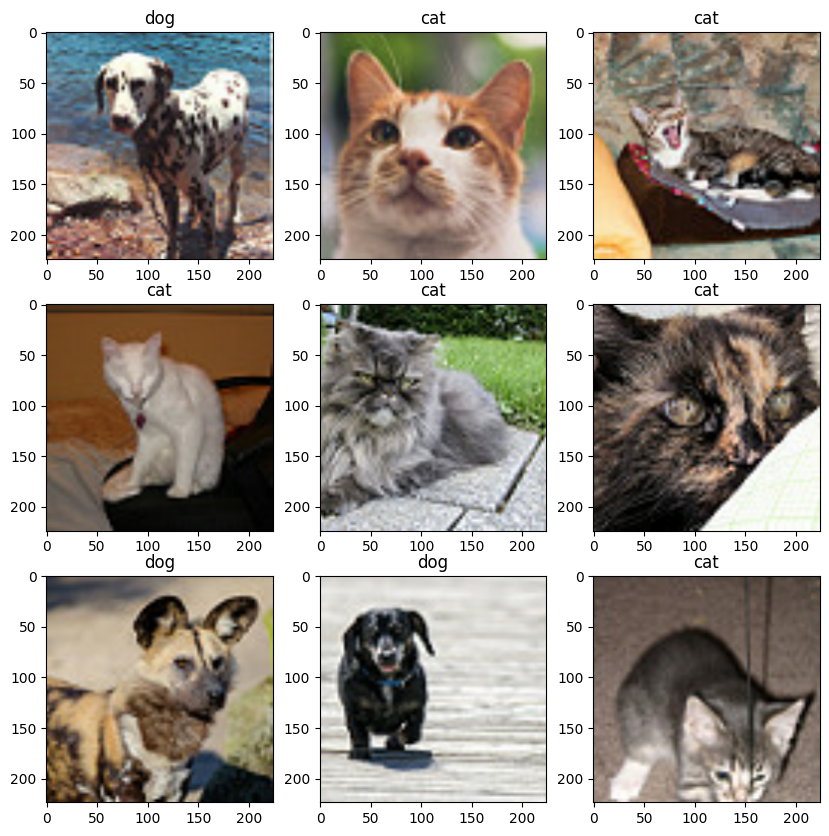

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [9]:
def flip_left_right(image, label):
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):
    image = tf.image.rot90(image, k=3)
    return image, label

In [10]:
train_dataset_lr = train_dataset.map(flip_left_right)
train_dataset_ud = train_dataset.map(flip_up_down)
train_dataset_rot90 = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [11]:
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [12]:
train_dataset = train_dataset.shuffle(32)

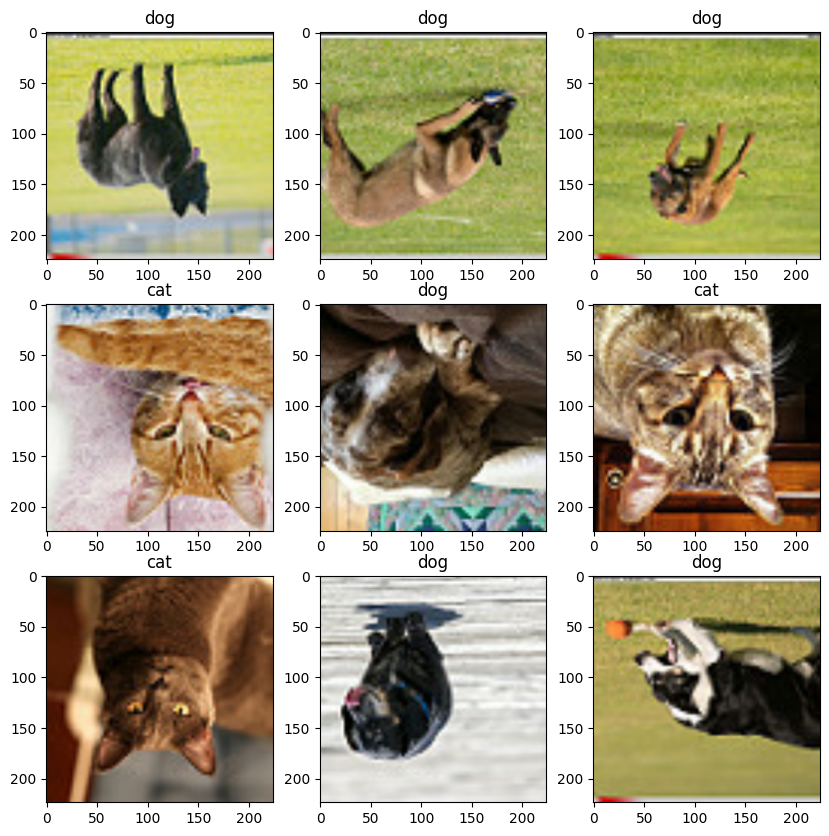

In [19]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [23]:
input_layer = tf.keras.Input(shape=(224, 224, 3))
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False

In [24]:
output_layer = tf.keras.layers.Dense(1, activation="sigmoid")

In [25]:
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [27]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [28]:
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 221ms/step - accuracy: 0.8094 - loss: 0.3984
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.9239 - loss: 0.2120
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.9467 - loss: 0.1642
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - accuracy: 0.9578 - loss: 0.1357
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9694 - loss: 0.1131
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9772 - loss: 0.0979
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step - accuracy: 0.9800 - loss: 0.0857
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - accuracy: 0.9833 - loss: 0.0786
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.9822 - loss: 0.0698
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9872 - loss: 0.0622
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - accuracy: 0.9889 - loss: 0.0565
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13

In [29]:
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step


In [30]:
pred_data

array([[1.2290677e-04],
       [1.7553859e-04],
       [3.3936973e-04],
       [1.2699607e-03],
       [1.9520526e-03],
       [2.7376393e-04],
       [4.9011171e-04],
       [9.3549635e-04],
       [1.8586350e-05],
       [2.7760319e-04],
       [7.4522752e-05],
       [6.8724812e-03],
       [3.2132980e-03],
       [5.8069022e-04],
       [1.0100156e-04],
       [4.4708886e-06],
       [9.0952672e-05],
       [3.3950887e-04],
       [2.5879082e-03],
       [2.3059605e-03],
       [2.6927567e-03],
       [7.0507139e-02],
       [3.8202170e-03],
       [8.2512182e-04],
       [2.4688406e-01],
       [2.0735976e-03],
       [1.1324751e-03],
       [1.0570966e-03],
       [7.7977981e-03],
       [1.5702790e-04],
       [4.5193810e-04],
       [8.4192109e-01],
       [4.4984557e-04],
       [5.8925565e-04],
       [8.9176307e-03],
       [9.1179186e-01],
       [6.8511348e-03],
       [1.0488898e-03],
       [2.7332610e-02],
       [4.0530864e-04],
       [4.1828473e-04],
       [7.472835

In [31]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.9600 - loss: 0.0718


[0.07180000096559525, 0.9599999785423279]